# Corpus927 KG Pilot — Exploratory Testing
**Goal:** Validate the `kg_pilot.py` pipeline step by step before running the full pipeline.

Run each cell in order. Each section is independent so you can re-run individual steps.

---

## 0 — Imports & Setup

In [3]:
import json
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx

from kg_pilot import (
    Corpus927Extractor,
    KGTransformer,
    NormaNode,
    CaseNode,
    run_pilot,
    build_networkx_graph,
    NORMA_ID,
    ARTIGO_ID,
)

extractor = Corpus927Extractor()
print("Setup OK")

Setup OK


---
## Step 1 — Raw API Probe
Fetch the raw JSON and inspect its structure **before** trusting the transformer.

Key question: do the top-level keys match what `KGTransformer.build()` expects?
Expected: `jurisprudencias`, `temas`, `posicionamentos_agrupados_stj`, `posicionamentos_isolados`

In [4]:
print(f"Fetching nrm:{NORMA_ID}|art:{ARTIGO_ID} ...")
api_data = extractor.fetch_jurisprudencia(NORMA_ID, ARTIGO_ID)

print("\n=== Top-level keys ===")
for key, val in api_data.items():
    vtype = type(val).__name__
    vlen  = len(val) if isinstance(val, (list, dict)) else "-"
    print(f"  {key:<40} type={vtype:<6}  len={vlen}")

Fetching nrm:1|art:18 ...

=== Top-level keys ===
  jurisprudencias                          type=dict    len=4
  temas                                    type=dict    len=2
  posicionamentos_agrupados_stj            type=list    len=30
  posicionamentos_agrupados_stj_emstj      type=list    len=0
  posicionamentos_isolados_stj             type=list    len=50
  alteracoes                               type=list    len=0


In [5]:
# ── Inspect 'jurisprudencias' sub-keys (type codes)
jurs = api_data.get("jurisprudencias", {})
print("=== jurisprudencias keys ===")
if isinstance(jurs, dict):
    for k, v in jurs.items():
        print(f"  key={k!r:<8}  items={len(v) if isinstance(v, list) else type(v).__name__}")
elif isinstance(jurs, list):
    print(f"  WARNING: 'jurisprudencias' is a LIST of {len(jurs)} items — check type codes!")
    if jurs:
        print("  First item keys:", list(jurs[0].keys()) if isinstance(jurs[0], dict) else jurs[0])
else:
    print(f"  Unexpected type: {type(jurs)}")

=== jurisprudencias keys ===
  key='70'      items=0
  key='90'      items=1
  key='100'     items=0
  key='110'     items=5


In [6]:
# ── Inspect 'temas' sub-keys
temas = api_data.get("temas", {})
print("=== temas keys ===")
if isinstance(temas, dict):
    for k, v in temas.items():
        print(f"  key={k!r:<8}  items={len(v) if isinstance(v, list) else type(v).__name__}")
    # Show first topic item keys if key '60' exists
    topics = temas.get("60", [])
    if topics:
        print("\n  First topic item keys:", list(topics[0].keys()))
        print("  Sample:", json.dumps(topics[0], ensure_ascii=False, indent=4)[:600])
else:
    print(f"  Unexpected type: {type(temas)}")

=== temas keys ===
  key='60'      items=2
  key='80'      items=0

  First topic item keys: ['id', 'codigo_tipo', 'titulo', 'conteudo', 'data_publicacao', 'tese', 'tema', 'situacao', 'url_origem', 'situacao_confirmada']
  Sample: {
    "id": 4794,
    "codigo_tipo": 60,
    "titulo": "Tema 449",
    "conteudo": "PROCESSUAL CIVIL. RECURSO ESPECIAL. AÇÃO DE PRESTAÇÃO DE CONTAS. PRAZO DECADENCIAL. artigo 26 DO CÓDIGO DE DEFESA DO CONSUMIDOR. NÃO INCIDÊNCIA. RECURSO REPRESENTATIVO DA CONTROVÉRSIA. <br><br>1.<mark title=\"Texto destacado pelos usuários\" class=\"highlight\"> O artigo 26 do Código de Defesa do Consumidor dispõe sobre o prazo decadencial para a reclamação por vícios em produtos ou serviços prestados ao consumidor, não sendo aplicável à ação de prestação de contas ajuizada pelo correntista com o escopo de obte


In [7]:
# ── Inspect grouped positions (leading cases)
grouped = api_data.get("posicionamentos_agrupados_stj", [])
print(f"=== posicionamentos_agrupados_stj: {len(grouped)} items ===")
if grouped:
    print("  Field keys:", list(grouped[0].keys()))
    print("\n  First item:")
    print(json.dumps(grouped[0], ensure_ascii=False, indent=4)[:800])

=== posicionamentos_agrupados_stj: 30 items ===
  Field keys: ['id', 'jurisprudencia_id', 'dispositivo_legal_id', 'semelhantes', 'created_at', 'updated_at', 'nome_corpus', 'titulo', 'data_publicacao', 'relator', 'conteudo', 'hash_it']

  First item:
{
    "id": 832045,
    "jurisprudencia_id": 665518,
    "dispositivo_legal_id": 78,
    "semelhantes": 34,
    "created_at": null,
    "updated_at": null,
    "nome_corpus": "mix",
    "titulo": "REsp 1556132",
    "data_publicacao": "2016-03-31",
    "relator": "MARIA THEREZA DE ASSIS MOURA",
    "conteudo": "AgRg no RECURSO ESPECIAL Nº 1.556.132 - SC (2015/0223916-4) RELATORA\t:\tMINISTRA MARIA THEREZA DE ASSIS MOURA AGRAVANTE\t:\tMINISTÉRIO PÚBLICO FEDERAL AGRAVADO\t:\tILSON ROBERTO RIGO ADVOGADA\t:\tRIZONI MARIA BALDISSERA BOGONI E OUTRO(S) INTERES.\t:\tMINISTÉRIO PÚBLICO DO ESTADO DE SANTA CATARINA EMENTA AGRAVO REGIMENTAL EM RECURSO ESPECIAL. PENAL. CRIME CONTRA AS RELAÇÕES DE CONSUMO. ARTIGO 7º, INCISO IX, DA LEI 8.137/90. EXPOR À V

In [8]:
# ── Inspect isolated positions
isolated = api_data.get("posicionamentos_isolados", [])
print(f"=== posicionamentos_isolados: {len(isolated)} items ===")
if isolated:
    print("  Field keys:", list(isolated[0].keys()))
    print("\n  First item:")
    print(json.dumps(isolated[0], ensure_ascii=False, indent=4)[:600])

=== posicionamentos_isolados: 0 items ===


---
## Step 2 — Run Pilot (without full-text fetch)
Runs the full transform pipeline using the already-fetched `api_data`.
This avoids a second HTTP request.

In [9]:
# Build KG directly from the api_data already in memory
norma_node  = NormaNode(node_id="CDC_art18", law="CDC", article=18)
transformer = KGTransformer(norma_node)
nodes, edges = transformer.build(api_data)

print(f"Nodes : {len(nodes)}")
print(f"Edges : {len(edges)}")

# Node type distribution
print("\nNode types:")
for ntype, count in Counter(getattr(n, 'node_type', '?') for n in nodes.values()).most_common():
    print(f"  {ntype:<38} {count:>4d}")

# Edge relation distribution
print("\nEdge relations:")
for rel, count in Counter(e.relation for e in edges).most_common():
    print(f"  {rel:<38} {count:>4d}")

Nodes : 41
Edges : 41

Node types:
  Case                                     30
  STJThesis                                 7
  RepetitiveTopic                           2
  LegalProvision                            1
  ConstitutionalControl                     1

Edge relations:
  INTERPRETED_BY_LEADING_CASE              30
  SUMMARIZED_BY_STJ_THESIS                  8
  INTERPRETED_BY_BINDING_THESIS             2
  CONTROLLED_BY                             1


In [10]:
# ── Symbolic validations (mirrors run_pilot Step 4)
checks = {
    "V1 – INTERPRETED_BY_BINDING_THESIS exists" : any(e.relation == "INTERPRETED_BY_BINDING_THESIS" for e in edges),
    "V2 – All weights in [0.0, 1.0]"            : all(0.0 <= e.weight <= 1.0 for e in edges),
    "V3 – All nodes typed"                      : all(getattr(n, 'node_type', '') != '' for n in nodes.values()),
    "V4 – CONTROLLED_BY from LegalProvision"    : all(
        getattr(nodes.get(e.source), 'node_type', '') == 'LegalProvision'
        for e in edges if e.relation == 'CONTROLLED_BY'
    ),
}
for label, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"  [{status}]  {label}")

  [PASS]  V1 – INTERPRETED_BY_BINDING_THESIS exists
  [PASS]  V2 – All weights in [0.0, 1.0]
  [PASS]  V3 – All nodes typed
  [PASS]  V4 – CONTROLLED_BY from LegalProvision


---
## Step 3 — Inspect Node Quality
Check whether the nodes were populated correctly: no empty titles, theses present, weight distribution reasonable.

In [11]:
# ── Sample nodes by type
from kg_pilot import TopicNode, STJThesisNode, ConstitutionalControlNode

for NodeClass, label in [
    (ConstitutionalControlNode, "ConstitutionalControl"),
    (TopicNode,                 "RepetitiveTopic"),
    (STJThesisNode,             "STJThesis"),
    (CaseNode,                  "Case"),
]:
    samples = [n for n in nodes.values() if isinstance(n, NodeClass)][:2]
    print(f"\n=== {label} (showing up to 2) ===")
    for s in samples:
        print(f"  id    : {s.node_id}")
        if hasattr(s, 'title'):        print(f"  title : {s.title[:80]}")
        if hasattr(s, 'thesis'):       print(f"  thesis: {s.thesis[:120]}")
        if hasattr(s, 'thesis_text'):  print(f"  text  : {s.thesis_text[:120]}")
        if hasattr(s, 'authority_weight'): print(f"  weight: {s.authority_weight}")
        print()


=== ConstitutionalControl (showing up to 2) ===
  id    : CC_ADI_5158
  title : ADI / 5158


=== RepetitiveTopic (showing up to 2) ===
  id    : Topic_449
  title : Tema 449
  thesis: A decadência do art. 26 do CDC não é aplicável à prestação de contas para obter esclarecimentos sobre cobrança de taxas,

  id    : Topic_200
  title : Tema 200
  thesis: Estão revestidas de legalidade as normas expedidas pelo CONMETRO e INMETRO, e suas respectivas infrações, com o objetivo


=== STJThesis (showing up to 2) ===
  id    : STJThesis_EDIÇÃO_N._83:_BANCÁRIO_-_II_t6
  text  : 6) Não há relação de acessoriedade entre o contrato de compra e venda de
bem de consumo e o de financiamento bancário co

  id    : STJThesis_EDIÇÃO_N._42:_DIREITO_DO_CONSUMIDOR_II_t5
  text  : 5) É cabível indenização por dano moral quando o consumidor de veículo
zero-quilômetro
necessita retornar à concessionár


=== Case (showing up to 2) ===
  id    : REsp_1556132
  title : REsp 1556132
  weight: 1.0

  id    : REsp_

In [12]:
# ── Authority weight distribution for CaseNodes
case_weights = [
    (n.title[:50], n.authority_weight, n.similar_count)
    for n in nodes.values() if isinstance(n, CaseNode)
]
case_weights.sort(key=lambda x: x[1], reverse=True)

print(f"Total CaseNodes: {len(case_weights)}")
print("\nTop-10 by authority_weight:")
for title, weight, sim in case_weights[:10]:
    print(f"  [{weight:.4f}]  similar={sim:<4d}  {title}")

if case_weights:
    weights_only = [w for _, w, _ in case_weights]
    print(f"\nWeight range: {min(weights_only):.4f} – {max(weights_only):.4f}")
    print(f"Isolated cases (weight=0.3): {sum(1 for w in weights_only if w == 0.3)}")

Total CaseNodes: 30

Top-10 by authority_weight:
  [1.0000]  similar=34    REsp 1556132
  [0.8563]  similar=20    REsp 1825020
  [0.7969]  similar=16    HC 263025
  [0.7969]  similar=16    REsp 1111736
  [0.7214]  similar=12    AREsp 627782
  [0.6744]  similar=10    REsp 1597668
  [0.6476]  similar=9     REsp 1060917
  [0.6180]  similar=8     AREsp 1691422
  [0.6180]  similar=8     REsp 1644405
  [0.6180]  similar=8     REsp 1737415

Weight range: 0.3899 – 1.0000
Isolated cases (weight=0.3): 0


In [13]:
# ── Export and verify JSON
from dataclasses import asdict

kg_data = {
    "metadata": {"norma_id": NORMA_ID, "artigo_id": ARTIGO_ID},
    "nodes": [asdict(n) for n in nodes.values()],
    "edges": [asdict(e) for e in edges],
}
with open("kg_pilot_art18.json", "w", encoding="utf-8") as f:
    json.dump(kg_data, f, ensure_ascii=False, indent=2)

# Reload and spot-check
with open("kg_pilot_art18.json") as f:
    saved = json.load(f)

print(f"JSON saved: {len(saved['nodes'])} nodes, {len(saved['edges'])} edges")
print("\nSample node from file:")
print(json.dumps(saved['nodes'][1], ensure_ascii=False, indent=2))

JSON saved: 41 nodes, 41 edges

Sample node from file:
{
  "node_id": "CC_ADI_5158",
  "node_type": "ConstitutionalControl",
  "title": "ADI / 5158",
  "summary": "Ementa: DIREITO CONSTITUCIONAL E CONSUMIDOR. AÇÃO DIRETA DE INCONSTITUCIONALIDADE. LEI 15.304/2014, DE PERNAMBUCO. IMPOSIÇÃO A MONTADORAS, CONCESSIONÁRIAS E IMPORTADORAS DE VEÍCULOS. FORNECIMENTO DE CARRO RESERVA EM REPAROS SUPERIORES A 15 DIAS, DURANTE GARANTIA CONTRATUAL. EXTRAPOLAÇÃO DE COMPETÊNCIA CONCORRENTE. INCONSTITUCIONALIDADE INTEGRAL DA LEI.   1. É inconstitucional,  por extrapolação de competência concorrente para legislar sobre matérias de consumo, lei estadual que impõe às montadoras, concessionárias e importadoras de veículos a obrigação de fornecer veículo reserva a clientes cu",
  "publication_date": "2019-02-19"
}


---
## Step 4 — Graph Visualization
Visualize the ego graph around `CDC_art18` (depth=1 = direct neighbors only).

DiGraph: 41 nodes, 40 edges
Ego graph (radius=1): 41 nodes, 40 edges


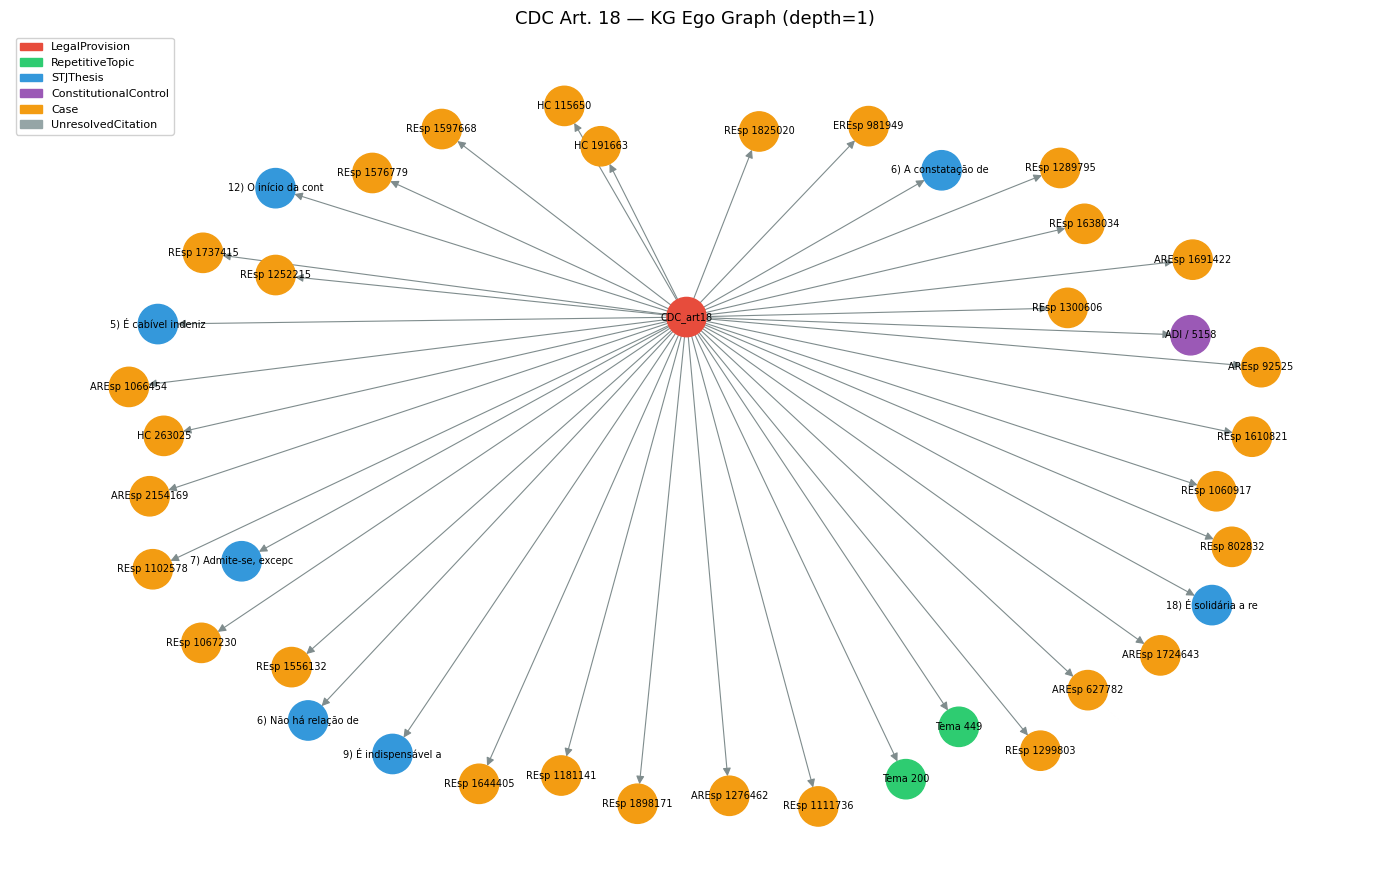

Saved: kg_art18_ego.png


In [14]:
G = build_networkx_graph(nodes, edges)
print(f"DiGraph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Color map by node type
COLOR_MAP = {
    "LegalProvision"      : "#e74c3c",
    "RepetitiveTopic"     : "#2ecc71",
    "STJThesis"           : "#3498db",
    "ConstitutionalControl": "#9b59b6",
    "Case"                : "#f39c12",
    "UnresolvedCitation"  : "#95a5a6",
}

# Ego graph: CDC_art18 + all direct neighbors
ego = nx.ego_graph(G, "CDC_art18", radius=1)
print(f"Ego graph (radius=1): {ego.number_of_nodes()} nodes, {ego.number_of_edges()} edges")

node_colors = [
    COLOR_MAP.get(ego.nodes[n].get("type", ""), "#bdc3c7")
    for n in ego.nodes()
]
node_labels = {
    n: ego.nodes[n].get("label", n)[:20]
    for n in ego.nodes()
}

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(ego, seed=42, k=2.5)
nx.draw_networkx(
    ego, pos, ax=ax,
    labels=node_labels,
    node_color=node_colors,
    node_size=800,
    font_size=7,
    arrows=True,
    arrowsize=12,
    edge_color="#7f8c8d",
    width=0.8,
)
# Legend
from matplotlib.patches import Patch
legend = [Patch(color=c, label=t) for t, c in COLOR_MAP.items()]
ax.legend(handles=legend, loc="upper left", fontsize=8, framealpha=0.9)
ax.set_title("CDC Art. 18 — KG Ego Graph (depth=1)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig("kg_art18_ego.png", dpi=150)
plt.show()
print("Saved: kg_art18_ego.png")

In [15]:
# ── Export GraphML for Gephi / Cytoscape
nx.write_graphml(G, "kg_pilot_art18.graphml")
print("Exported: kg_pilot_art18.graphml")

Exported: kg_pilot_art18.graphml
